In [3]:
import deeplenstronomy.deeplenstronomy as dl
from deeplenstronomy.visualize import view_image, view_image_rgb

In [4]:
!pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 MB 3.2 MB/s eta 0:00:0000:0100:01
  Using cached absl_py-1.1.0-py3-none-any.whl (123 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 8.3 MB/s eta 0:00:0000:0100:01
  Using cached termcolor-1.1.0.tar.gz (3.9 kB)
  Preparing metadata (setup.py) ... done
  Using cached gast-0.4.0-py3-none-any.whl (9.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.8/960.8 kB 7.2 MB/s eta 0:00:0000:0100:01
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached Keras_Preprocessing-1.1.2-py2.py3-none-any.whl (42 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.0 MB/s eta 0:00:0000:0100:01m
  Using cached tensorflow_estimator-2.9.0-py2.py3-none-any.whl (438 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached opt_einsum-3.3.0-py3-none-any.whl (65 kB)
  Using cached libclang-14.0.1-py2.py3-none-macosx_10_9_x86_64.whl (13.2 MB)
  Using cached keras-2.9.0-py2.py3-none-any.whl (1

In [5]:
import numpy as np
# plotting
from matplotlib import pyplot as plt

# keras
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Input, Flatten, Dense, Activation, Dropout, BatchNormalization
from keras.layers.convolutional import Convolution2D, MaxPooling2D
from keras.regularizers import l2
from keras.callbacks import EarlyStopping

# sklearn (for machine learning)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [75]:
dataset2 = dl.make_dataset('simple2.yaml',store_in_memory=True, save_to_disk=True,image_file_format='npy', verbose=True)

Entering main organization loop
Organizing CONFIGURATION_1
Organizing CONFIGURATION_2
Generating images for CONFIGURATION_1
	Progress: 100.0 %  ---  Elapsed Time: 0 H 0 M 0 S         
Generating images for CONFIGURATION_2
	Progress: 100.0 %  ---  Elapsed Time: 0 H 0 M 0 S         


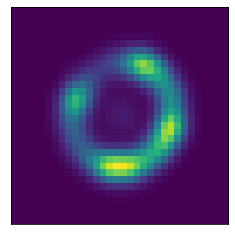

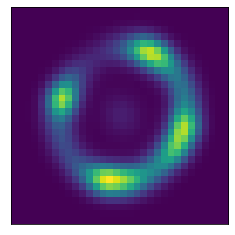

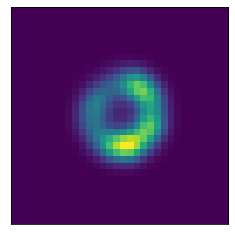

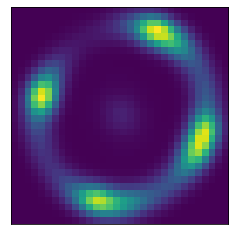

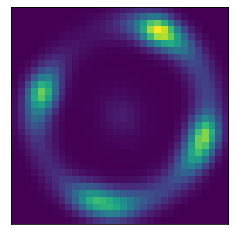

In [76]:
for i in range (5):
    view_image(dataset.CONFIGURATION_1_images[i][0])

CNN network

In [77]:
#upload data
X1=np.load('/Users/Zhaoyifan/Deeplens/SimpleDataset2/CONFIGURATION_1_images.npy',allow_pickle=True)
X2=np.load('/Users/Zhaoyifan/Deeplens/SimpleDataset2/CONFIGURATION_2_images.npy',allow_pickle=True)

In [78]:
X=np.concatenate((X1,X2))

In [79]:
print(X1.shape)
print(X2.shape)
print(X.shape)
#print(X[0])

(49, 1, 32, 32)
(49, 1, 32, 32)
(98, 1, 32, 32)


In [80]:
y1=np.ones(49)
y2=np.zeros(49)
y=np.concatenate((y1,y2))
#y.shape

In [81]:
X = np.asarray(X).astype('float32')
y = np.asarray(y).astype('float32')

In [82]:
#split data
# First split off 30% of the data for validation+testing
X_train, X_split, y_train, y_split = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

# Then divide this subset into training and testing sets
X_valid, X_test, y_valid, y_test = train_test_split(X_split, y_split, test_size=0.666, random_state=42, shuffle=True)

In [83]:
imsize = np.shape(X_train)[2]

X_train = X_train.reshape(-1, imsize, imsize, 1)
X_valid = X_valid.reshape(-1, imsize, imsize, 1)
X_test = X_test.reshape(-1, imsize, imsize, 1)

CNN network

In [111]:
#from Alek galaxy paper
# Define architecture for model
data_shape = np.shape(X)
input_shape = (imsize, imsize, 1)

x_in = Input(shape=input_shape)
c0 = Convolution2D(8, (5, 5), activation='relu', strides=(1, 1), padding='same')(x_in)
b0 = BatchNormalization()(c0)
d0 = MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid')(b0)
e0 = Dropout(0.5)(d0)

c1 = Convolution2D(16, (3, 3), activation='relu', strides=(1, 1), padding='same')(e0)
b1 = BatchNormalization()(c1)
d1 = MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid')(b1)
e1 = Dropout(0.5)(d1)

c2 = Convolution2D(32, (3, 3), activation='relu', strides=(1, 1), padding='same')(e1)
b2 = BatchNormalization()(c2)
d2 = MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid')(b2)
e2 = Dropout(0.5)(d2)

f = Flatten()(e2)
z0 = Dense(64, activation='softmax', kernel_regularizer=l2(0.0001))(f)
z1 = Dense(32, activation='softmax', kernel_regularizer=l2(0.0001))(z0)
y_out = Dense(1, activation='sigmoid')(z1)

model = Model(inputs=x_in, outputs=y_out)

In [112]:
# Compile Model
optimizer = 'adam'
metrics = ['accuracy']
loss = 'binary_crossentropy'
model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 32, 32, 1)]       0         
                                                                 
 conv2d_21 (Conv2D)          (None, 32, 32, 8)         208       
                                                                 
 batch_normalization_15 (Bat  (None, 32, 32, 8)        32        
 chNormalization)                                                
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 16, 16, 8)        0         
 g2D)                                                            
                                                                 
 dropout_24 (Dropout)        (None, 16, 16, 8)         0         
                                                                 
 conv2d_22 (Conv2D)          (None, 16, 16, 16)        1168

In [113]:
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
model = Sequential()
#
model.add(Conv2D(filters = 8, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu', input_shape = (32,32,1)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.5))
#
model.add(Conv2D(filters = 16, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.5))
# fully connected
model.add(Flatten())
model.add(Dense(64, activation = "softmax"))
model.add(Dense(32, activation = "softmax"))
model.add(Dense(1,activation= "sigmoid"))

In [114]:
# Compile Model
optimizer = 'adam'
metrics = ['accuracy']
loss = 'binary_crossentropy'
model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_24 (Conv2D)          (None, 32, 32, 8)         208       
                                                                 
 batch_normalization_18 (Bat  (None, 32, 32, 8)        32        
 chNormalization)                                                
                                                                 
 max_pooling2d_24 (MaxPoolin  (None, 16, 16, 8)        0         
 g2D)                                                            
                                                                 
 dropout_27 (Dropout)        (None, 16, 16, 8)         0         
                                                                 
 conv2d_25 (Conv2D)          (None, 16, 16, 16)        1168      
                                                                 
 batch_normalization_19 (Bat  (None, 16, 16, 16)      

In [115]:
nb_epoch = 500
batch_size = 128
shuffle = True

# Train
history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=nb_epoch,
                    validation_data=(X_valid, y_valid),                
                    shuffle=shuffle,
                    verbose=True)

Epoch 1/500
1/1 [==============================] - 1s 778ms/step - loss: 0.6932 - accuracy: 0.5294 - val_loss: 0.6930 - val_accuracy: 0.6000
Epoch 2/500
1/1 [==============================] - 0s 56ms/step - loss: 0.6924 - accuracy: 0.5294 - val_loss: 0.6925 - val_accuracy: 0.6000
Epoch 3/500
1/1 [==============================] - 0s 65ms/step - loss: 0.6920 - accuracy: 0.5294 - val_loss: 0.6922 - val_accuracy: 0.6000
Epoch 4/500
1/1 [==============================] - 0s 62ms/step - loss: 0.6915 - accuracy: 0.5294 - val_loss: 0.6919 - val_accuracy: 0.6000
Epoch 5/500
1/1 [==============================] - 0s 48ms/step - loss: 0.6911 - accuracy: 0.5294 - val_loss: 0.6917 - val_accuracy: 0.6000
Epoch 6/500
1/1 [==============================] - 0s 47ms/step - loss: 0.6906 - accuracy: 0.5294 - val_loss: 0.6913 - val_accuracy: 0.6000
Epoch 7/500
1/1 [==============================] - 0s 46ms/step - loss: 0.6901 - accuracy: 0.5294 - val_loss: 0.6911 - val_accuracy: 0.6000
Epoch 8/500
1/1 [==

1/1 [==============================] - 0s 46ms/step - loss: 0.6764 - accuracy: 0.5294 - val_loss: 0.6742 - val_accuracy: 0.6000
Epoch 60/500
1/1 [==============================] - 0s 45ms/step - loss: 0.6761 - accuracy: 0.5294 - val_loss: 0.6733 - val_accuracy: 0.6000
Epoch 61/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6759 - accuracy: 0.5294 - val_loss: 0.6726 - val_accuracy: 0.6000
Epoch 62/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6756 - accuracy: 0.5294 - val_loss: 0.6718 - val_accuracy: 0.6000
Epoch 63/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6753 - accuracy: 0.5294 - val_loss: 0.6711 - val_accuracy: 0.6000
Epoch 64/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6751 - accuracy: 0.5294 - val_loss: 0.6705 - val_accuracy: 0.6000
Epoch 65/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6748 - accuracy: 0.5294 - val_loss: 0.6699 - val_accuracy: 0.6000
Epoch 66/500
1/1 [========

1/1 [==============================] - 0s 42ms/step - loss: 0.6594 - accuracy: 0.5294 - val_loss: 0.6517 - val_accuracy: 0.6000
Epoch 118/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6590 - accuracy: 0.5294 - val_loss: 0.6514 - val_accuracy: 0.6000
Epoch 119/500
1/1 [==============================] - 0s 41ms/step - loss: 0.6587 - accuracy: 0.5294 - val_loss: 0.6510 - val_accuracy: 0.6000
Epoch 120/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6584 - accuracy: 0.5294 - val_loss: 0.6507 - val_accuracy: 0.6000
Epoch 121/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6580 - accuracy: 0.5294 - val_loss: 0.6503 - val_accuracy: 0.6000
Epoch 122/500
1/1 [==============================] - 0s 41ms/step - loss: 0.6577 - accuracy: 0.5294 - val_loss: 0.6500 - val_accuracy: 0.6000
Epoch 123/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6573 - accuracy: 0.5294 - val_loss: 0.6496 - val_accuracy: 0.6000
Epoch 124/500
1/1 [=

Epoch 175/500
1/1 [==============================] - 0s 44ms/step - loss: 0.6366 - accuracy: 1.0000 - val_loss: 0.6287 - val_accuracy: 1.0000
Epoch 176/500
1/1 [==============================] - 0s 40ms/step - loss: 0.6362 - accuracy: 1.0000 - val_loss: 0.6282 - val_accuracy: 1.0000
Epoch 177/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6357 - accuracy: 1.0000 - val_loss: 0.6278 - val_accuracy: 1.0000
Epoch 178/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6353 - accuracy: 1.0000 - val_loss: 0.6274 - val_accuracy: 1.0000
Epoch 179/500
1/1 [==============================] - 0s 41ms/step - loss: 0.6348 - accuracy: 1.0000 - val_loss: 0.6269 - val_accuracy: 1.0000
Epoch 180/500
1/1 [==============================] - 0s 41ms/step - loss: 0.6344 - accuracy: 1.0000 - val_loss: 0.6265 - val_accuracy: 1.0000
Epoch 181/500
1/1 [==============================] - 0s 41ms/step - loss: 0.6339 - accuracy: 1.0000 - val_loss: 0.6260 - val_accuracy: 1.0000
Epoch 

Epoch 233/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6083 - accuracy: 1.0000 - val_loss: 0.6006 - val_accuracy: 1.0000
Epoch 234/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6078 - accuracy: 1.0000 - val_loss: 0.6001 - val_accuracy: 1.0000
Epoch 235/500
1/1 [==============================] - 0s 44ms/step - loss: 0.6073 - accuracy: 1.0000 - val_loss: 0.5996 - val_accuracy: 1.0000
Epoch 236/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6067 - accuracy: 1.0000 - val_loss: 0.5990 - val_accuracy: 1.0000
Epoch 237/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6062 - accuracy: 1.0000 - val_loss: 0.5985 - val_accuracy: 1.0000
Epoch 238/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6057 - accuracy: 1.0000 - val_loss: 0.5980 - val_accuracy: 1.0000
Epoch 239/500
1/1 [==============================] - 0s 43ms/step - loss: 0.6051 - accuracy: 1.0000 - val_loss: 0.5975 - val_accuracy: 1.0000
Epoch 

Epoch 291/500
1/1 [==============================] - 0s 43ms/step - loss: 0.5761 - accuracy: 1.0000 - val_loss: 0.5688 - val_accuracy: 1.0000
Epoch 292/500
1/1 [==============================] - 0s 42ms/step - loss: 0.5755 - accuracy: 1.0000 - val_loss: 0.5682 - val_accuracy: 1.0000
Epoch 293/500
1/1 [==============================] - 0s 41ms/step - loss: 0.5749 - accuracy: 1.0000 - val_loss: 0.5676 - val_accuracy: 1.0000
Epoch 294/500
1/1 [==============================] - 0s 42ms/step - loss: 0.5743 - accuracy: 1.0000 - val_loss: 0.5671 - val_accuracy: 1.0000
Epoch 295/500
1/1 [==============================] - 0s 42ms/step - loss: 0.5737 - accuracy: 1.0000 - val_loss: 0.5665 - val_accuracy: 1.0000
Epoch 296/500
1/1 [==============================] - 0s 42ms/step - loss: 0.5731 - accuracy: 1.0000 - val_loss: 0.5659 - val_accuracy: 1.0000
Epoch 297/500
1/1 [==============================] - 0s 43ms/step - loss: 0.5726 - accuracy: 1.0000 - val_loss: 0.5653 - val_accuracy: 1.0000
Epoch 

Epoch 349/500
1/1 [==============================] - 0s 42ms/step - loss: 0.5414 - accuracy: 1.0000 - val_loss: 0.5347 - val_accuracy: 1.0000
Epoch 350/500
1/1 [==============================] - 0s 44ms/step - loss: 0.5408 - accuracy: 1.0000 - val_loss: 0.5341 - val_accuracy: 1.0000
Epoch 351/500
1/1 [==============================] - 0s 42ms/step - loss: 0.5402 - accuracy: 1.0000 - val_loss: 0.5335 - val_accuracy: 1.0000
Epoch 352/500
1/1 [==============================] - 0s 43ms/step - loss: 0.5396 - accuracy: 1.0000 - val_loss: 0.5329 - val_accuracy: 1.0000
Epoch 353/500
1/1 [==============================] - 0s 44ms/step - loss: 0.5390 - accuracy: 1.0000 - val_loss: 0.5323 - val_accuracy: 1.0000
Epoch 354/500
1/1 [==============================] - 0s 42ms/step - loss: 0.5384 - accuracy: 1.0000 - val_loss: 0.5317 - val_accuracy: 1.0000
Epoch 355/500
1/1 [==============================] - 0s 43ms/step - loss: 0.5377 - accuracy: 1.0000 - val_loss: 0.5311 - val_accuracy: 1.0000
Epoch 

Epoch 407/500
1/1 [==============================] - 0s 44ms/step - loss: 0.5058 - accuracy: 1.0000 - val_loss: 0.4996 - val_accuracy: 1.0000
Epoch 408/500
1/1 [==============================] - 0s 43ms/step - loss: 0.5052 - accuracy: 1.0000 - val_loss: 0.4990 - val_accuracy: 1.0000
Epoch 409/500
1/1 [==============================] - 0s 44ms/step - loss: 0.5045 - accuracy: 1.0000 - val_loss: 0.4984 - val_accuracy: 1.0000
Epoch 410/500
1/1 [==============================] - 0s 44ms/step - loss: 0.5039 - accuracy: 1.0000 - val_loss: 0.4978 - val_accuracy: 1.0000
Epoch 411/500
1/1 [==============================] - 0s 42ms/step - loss: 0.5033 - accuracy: 1.0000 - val_loss: 0.4971 - val_accuracy: 1.0000
Epoch 412/500
1/1 [==============================] - 0s 44ms/step - loss: 0.5027 - accuracy: 1.0000 - val_loss: 0.4965 - val_accuracy: 1.0000
Epoch 413/500
1/1 [==============================] - 0s 44ms/step - loss: 0.5021 - accuracy: 1.0000 - val_loss: 0.4959 - val_accuracy: 1.0000
Epoch 

Epoch 465/500
1/1 [==============================] - 0s 46ms/step - loss: 0.4703 - accuracy: 1.0000 - val_loss: 0.4646 - val_accuracy: 1.0000
Epoch 466/500
1/1 [==============================] - 0s 45ms/step - loss: 0.4697 - accuracy: 1.0000 - val_loss: 0.4640 - val_accuracy: 1.0000
Epoch 467/500
1/1 [==============================] - 0s 44ms/step - loss: 0.4691 - accuracy: 1.0000 - val_loss: 0.4634 - val_accuracy: 1.0000
Epoch 468/500
1/1 [==============================] - 0s 44ms/step - loss: 0.4685 - accuracy: 1.0000 - val_loss: 0.4628 - val_accuracy: 1.0000
Epoch 469/500
1/1 [==============================] - 0s 44ms/step - loss: 0.4679 - accuracy: 1.0000 - val_loss: 0.4622 - val_accuracy: 1.0000
Epoch 470/500
1/1 [==============================] - 0s 44ms/step - loss: 0.4672 - accuracy: 1.0000 - val_loss: 0.4616 - val_accuracy: 1.0000
Epoch 471/500
1/1 [==============================] - 0s 43ms/step - loss: 0.4666 - accuracy: 1.0000 - val_loss: 0.4610 - val_accuracy: 1.0000
Epoch 

result

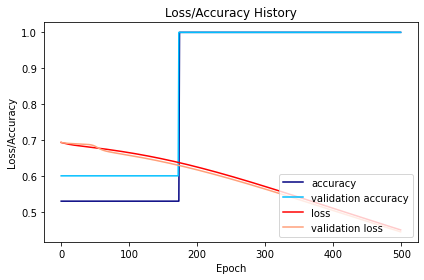

In [116]:
# plotting from history

loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = list(range(len(loss)))
figsize=(6,4)
fig, axis1 = plt.subplots(figsize=figsize)
plot1_lacc = axis1.plot(epochs, acc, 'navy', label='accuracy')
plot1_val_lacc = axis1.plot(epochs, val_acc, 'deepskyblue', label="validation accuracy")

plot1_loss = axis1.plot(epochs, loss, 'red', label='loss')
plot1_val_loss = axis1.plot(epochs, val_loss, 'lightsalmon', label="validation loss")


plots = plot1_loss + plot1_val_loss
labs = [l.get_label() for l in plots]
axis1.set_xlabel('Epoch')
axis1.set_ylabel('Loss/Accuracy')
plt.title("Loss/Accuracy History")
plt.tight_layout()
axis1.legend(loc='lower right')

In [117]:
score = model.evaluate(X_test, y_test, verbose=True)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

1/1 [==============================] - 0s 22ms/step - loss: 0.4608 - accuracy: 1.0000
accuracy: 100.00%


1/1 [==============================] - 0s 74ms/step


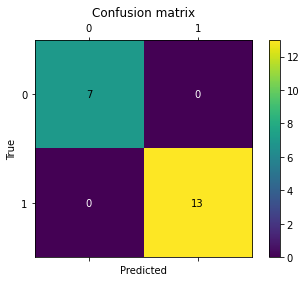

In [118]:
# predict
prob = model.predict(X_test)
pred =  (prob > 0.5).astype('int32') 

# measure confusion
labels=[0, 1]
cm = confusion_matrix(y_test, pred, labels=labels)
cm = cm.astype('float') # regular CM
cm_norm = cm / cm.sum(axis=1)[:, np.newaxis] # normalized CM


#plotting
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Confusion matrix', y=1.08)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('True')
fmt = '.0f'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], fmt),
        ha="center", va="center",
        color="white" if cm[i, j] < thresh else "black")
plt.show()

In [119]:
print(prob)
print(pred)

[[0.3409084 ]
 [0.616049  ]
 [0.61604786]
 [0.6160492 ]
 [0.6160432 ]
 [0.61604923]
 [0.6160477 ]
 [0.61604893]
 [0.61604923]
 [0.3409084 ]
 [0.3409084 ]
 [0.6160493 ]
 [0.3409084 ]
 [0.6160492 ]
 [0.3409084 ]
 [0.3409084 ]
 [0.6160486 ]
 [0.3409084 ]
 [0.61604923]
 [0.61604923]]
[[0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]]


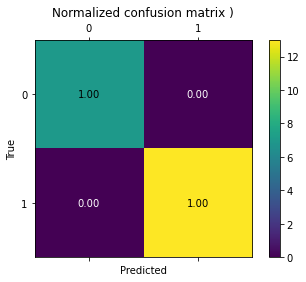

In [120]:
#plotting
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Normalized confusion matrix )', y=1.08)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('True')
fmt = '.2f'
thresh = cm_norm.max() / 2.
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, format(cm_norm[i, j], fmt),
        ha="center", va="center",
        color="white" if cm_norm[i, j] < thresh else "black")
plt.show()

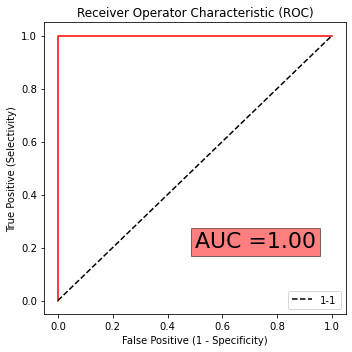

In [121]:
fpr, tpr, thresholds = roc_curve(y_test, prob, pos_label=1)
auc = roc_auc_score(y_test, prob)


figsize=(5,5)
fig, axis1 = plt.subplots(figsize=figsize)
x_onetoone = y_onetoone = [0, 1]
plt.plot(fpr, tpr, 'r-')
plt.plot(x_onetoone, y_onetoone, 'k--',  label="1-1")
plt.legend(loc=0)
plt.title("Receiver Operator Characteristic (ROC)")
plt.xlabel("False Positive (1 - Specificity)")
plt.ylabel("True Positive (Selectivity)")
#Adding text inside a rectangular box by using the keyword 'bbox'
plt.text(0.5, 0.2, "AUC ="+"{0:.2f}".format(auc), fontsize = 22, 
         bbox = dict(facecolor = 'red', alpha = 0.5))
plt.tight_layout()

In [122]:
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, pred)
print('Accuracy: %f' % accuracy)

# precision tp / (tp + fp)
precision = precision_score(y_test, pred)
print('Precision: %f' % precision)

# recall: tp / (tp + fn)
recall = recall_score(y_test, pred)
print('Recall: %f' % recall)

# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, pred)
print('F1 score: %f' % f1)

Accuracy: 1.000000
Precision: 1.000000
Recall: 1.000000
F1 score: 1.000000
